# 02 — Dataset Construction & Sanity Checks

Week 2 deliverable (CLAUDE.md §10). Sanity-checks the labelled possessions built by
`data/possessions.py` + `data/labels.py` (run `make data` first):

1. Shape, columns, and label completeness of `possessions.parquet`.
2. Success rate by competition.
3. Success / xT by slice (counter vs open play vs set piece).
4. Distribution of `xt_progression`.
5. Spatial distribution of trigger locations and attacker-run targets.
6. Visible-player counts (the ≥10 filter).
7. The learned 16×12 xT grid.

Reads only local caches — no network.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mplsoccer import Pitch

pd.set_option("display.max_columns", 50)
DATA = ROOT / "data" / "processed"

df = pd.read_parquet(DATA / "possessions.parquet")
print("rows:", len(df), "| cols:", len(df.columns))
print("columns:", list(df.columns))
df.head()

rows: 17506 | cols: 23
columns: ['match_id', 'possession', 'possession_team', 'period', 'trigger_event_id', 'trigger_time_s', 'trigger_x', 'trigger_y', 'end_x', 'end_y', 'play_pattern', 'from_counter', 'from_set_piece', 'run_target_event_id', 'n_events', 'competition_name', 'season_name', 'is_target', 'n_visible', 'success', 'xt_progression', 'run_target_x', 'run_target_y']


,match_id,possession,possession_team,period,trigger_event_id,trigger_time_s,trigger_x,trigger_y,end_x,end_y,play_pattern,from_counter,from_set_piece,run_target_event_id,n_events,competition_name,season_name,is_target,n_visible,success,xt_progression,run_target_x,run_target_y
0,3895052,2,RB Leipzig,1,ebaf6e35-461e-411b-a4c6-bd8c8807ed4b,21.691,85.0,63.5,115.1,13.3,From Kick Off,False,False,bf131dfc-aa54-477b-aa3a-fe427e0f5a4d,34,1. Bundesliga,2023/2024,True,20,True,0.046538,88.628479,50.370071
1,3895052,3,RB Leipzig,1,87666b3c-fae0-4ec8-a71d-c2d3be7beb84,46.278,113.5,0.1,68.7,76.2,From Throw In,False,True,351f7fc6-14b7-46ba-9fb9-04f41961ded3,19,1. Bundesliga,2023/2024,True,16,False,-0.061500,106.777367,10.489800
2,3895052,6,Bayer Leverkusen,1,6aa04e2b-f226-4e4c-84a1-6438d188c9a6,112.588,94.4,61.6,92.2,27.1,Regular Play,False,False,ed61d850-a665-4e5e-a9b4-fa4860cd73a9,16,1. Bundesliga,2023/2024,True,17,True,0.000483,104.401936,61.313669
3,3895052,9,Bayer Leverkusen,1,8861d98d-8203-4cf2-a8cd-292630b66f01,137.739,80.7,68.0,98.0,67.2,Regular Play,False,False,2e82cdf4-082a-4d1e-9590-c48cd417ba08,13,1. Bundesliga,2023/2024,True,18,True,0.020028,92.121860,67.866352
4,3895052,12,Bayer Leverkusen,1,ddce2c99-b9aa-4b00-a4e2-733e446ea69f,188.800,82.7,71.4,108.1,55.6,Regular Play,False,False,2d4f5aa2-50a7-441f-9e21-8af732fbff55,58,1. Bundesliga,2023/2024,True,20,False,0.065202,106.304039,59.278903


## 1. Shape & label completeness

Every kept possession must have all three targets populated (rows that couldn't be
labelled were dropped upstream).

In [2]:
labels = ["success", "xt_progression", "run_target_x", "run_target_y"]
print("label NaNs:", {c: int(df[c].isna().sum()) for c in labels})
print("success rate:", round(df["success"].mean(), 3))
print("by is_target:")
print(df.groupby("is_target").size())
cols = ["success", "xt_progression", "run_target_x", "run_target_y", "n_visible", "trigger_x"]
df[cols].describe()

label NaNs: {'success': 0, 'xt_progression': 0, 'run_target_x': 0, 'run_target_y': 0}
success rate: 0.458
by is_target:
is_target
False     4329
True     13177
dtype: int64


,xt_progression,run_target_x,run_target_y,n_visible,trigger_x
count,17506.000000,17506.000000,17506.000000,17506.000000,17506.000000
mean,0.047263,97.106287,40.268830,15.804924,91.328310
std,0.068310,10.913684,17.074694,2.797036,11.148136
min,-0.172514,28.454836,-5.958606,10.000000,80.000000
25%,0.000783,91.621858,30.122047,14.000000,83.200000
50%,0.025253,97.345319,40.005607,16.000000,87.200000
75%,0.072537,103.773639,50.400002,18.000000,95.500000
max,0.288405,122.187105,86.125999,22.000000,120.000000


## 2. Success rate by competition

Pooled across all 360 competitions (target + extras). Bars vs. the overall mean.

,n,success_rate
competition_name,,
UEFA Euro,4196,0.462
Women's World Cup,2744,0.443
FIFA World Cup,2524,0.420
UEFA Women's Euro,2500,0.521
Ligue 1,2436,0.434
La Liga,1776,0.443
1. Bundesliga,1213,0.505
Major League Soccer,117,0.436


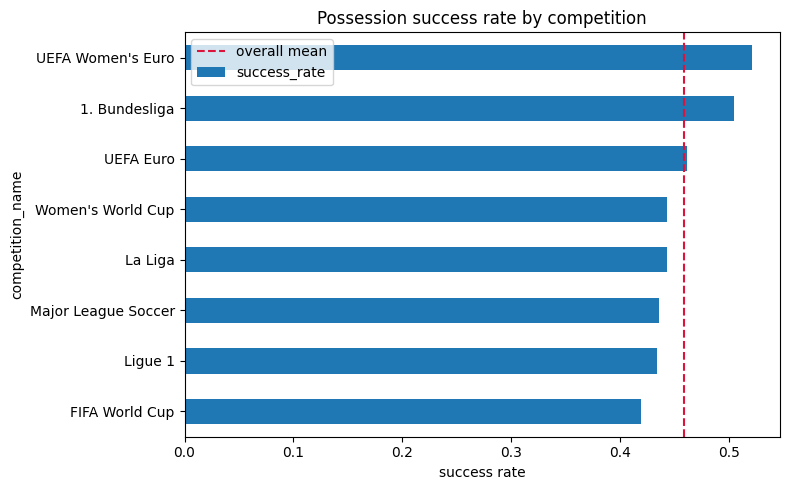

In [3]:
by_comp = (
    df.groupby("competition_name")
    .agg(n=("success", "size"), success_rate=("success", "mean"))
    .sort_values("n", ascending=False)
)
display(by_comp.round(3))

ax = by_comp["success_rate"].sort_values().plot.barh(figsize=(8, 5), color="#1f77b4")
ax.axvline(df["success"].mean(), color="crimson", ls="--", label="overall mean")
ax.set_xlabel("success rate")
ax.set_title("Possession success rate by competition")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Success & xT by slice

The key sanity signal: **counter-attacks should be far more successful** than open
play. If the labels reproduce that on their own, they are meaningful.

,n,success_rate,xt_mean
all,17506,0.458,0.0473
counter,269,0.807,0.0651
non-counter,17237,0.453,0.0470
open play,11976,0.447,0.0504
from set piece,5530,0.482,0.0404


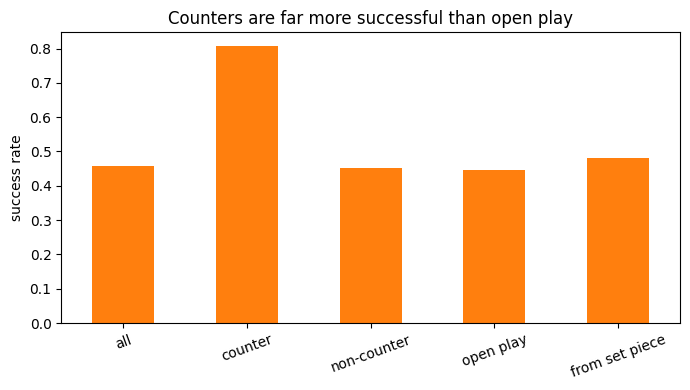

In [4]:
slices = {
    "all": df,
    "counter": df[df["from_counter"]],
    "non-counter": df[~df["from_counter"]],
    "open play": df[~df["from_set_piece"]],
    "from set piece": df[df["from_set_piece"]],
}
summary = pd.DataFrame(
    {
        "n": {k: len(v) for k, v in slices.items()},
        "success_rate": {k: round(v["success"].mean(), 3) for k, v in slices.items()},
        "xt_mean": {k: round(v["xt_progression"].mean(), 4) for k, v in slices.items()},
    }
)
display(summary)

ax = summary["success_rate"].plot.bar(figsize=(7, 4), color="#ff7f0e", rot=20)
ax.set_ylabel("success rate")
ax.set_title("Counters are far more successful than open play")
plt.tight_layout()
plt.show()

## 4. Distribution of xT progression

`xt_progression = xT(end) - xT(trigger)`. Centred slightly positive (attacking-third
possessions tend to add threat); a left tail for moves that lose ground.

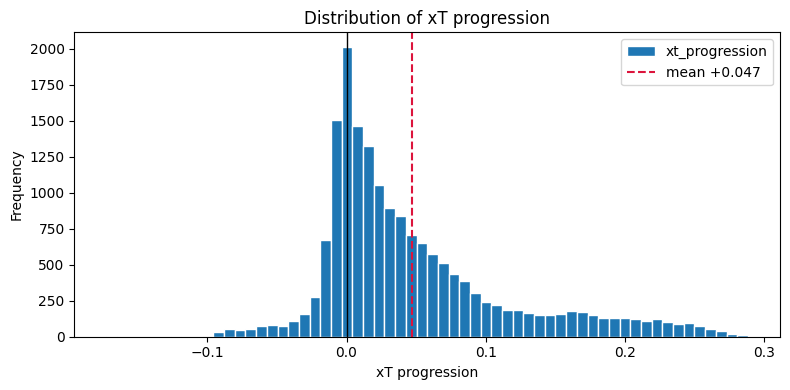

In [5]:
ax = df["xt_progression"].plot.hist(bins=60, figsize=(8, 4), edgecolor="white")
ax.axvline(0, color="black", lw=1)
ax.axvline(
    df["xt_progression"].mean(),
    color="crimson",
    ls="--",
    label=f"mean {df['xt_progression'].mean():+.3f}",
)
ax.set_xlabel("xT progression")
ax.set_title("Distribution of xT progression")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Spatial distribution: triggers and run targets

Triggers cluster at the attacking-third boundary (x≈80) and beyond; run targets
(furthest-forward attacker, ~1.5 s later) should sit in advanced areas.

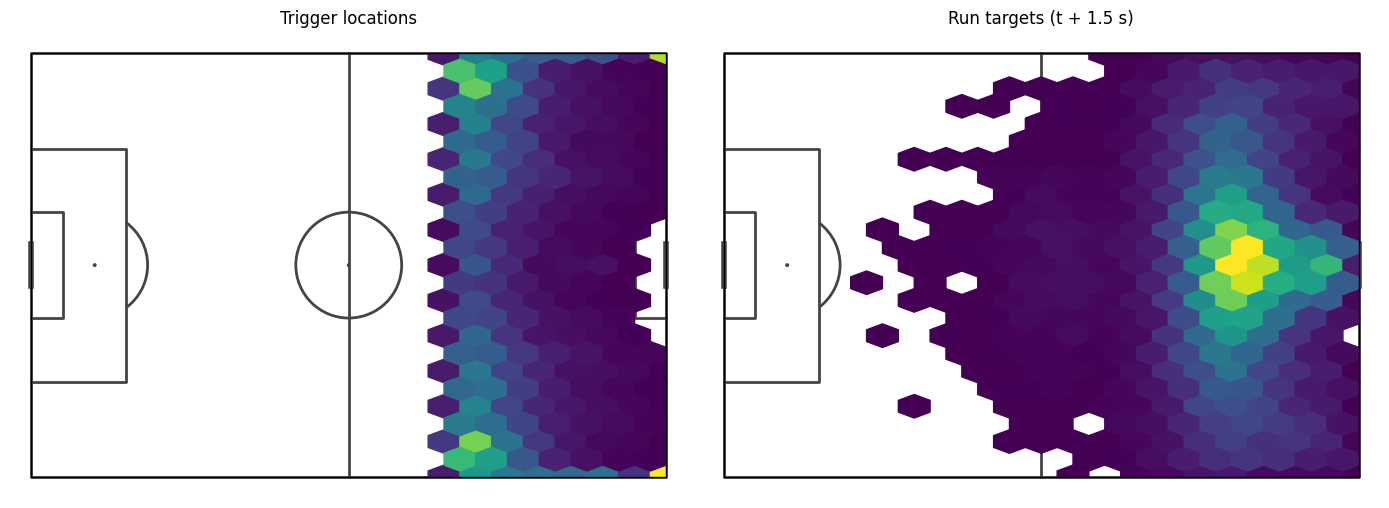

In [6]:
pitch = Pitch(pitch_type="statsbomb", line_color="#444444")
fig, axes = pitch.draw(figsize=(14, 6), nrows=1, ncols=2)
panels = [
    ("trigger_x", "trigger_y", "Trigger locations"),
    ("run_target_x", "run_target_y", "Run targets (t + 1.5 s)"),
]
for ax, (cx, cy, title) in zip(axes, panels, strict=False):
    pitch.hexbin(df[cx], df[cy], ax=ax, gridsize=(20, 12), cmap="viridis", mincnt=1)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 6. Visible-player counts (≥10 filter)

All kept rows have ≥10 visible players at the trigger (CLAUDE.md §4.3).

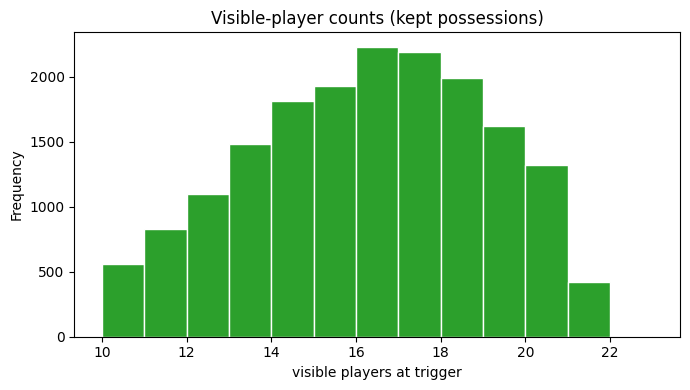

In [7]:
ax = df["n_visible"].plot.hist(
    bins=range(10, 24), figsize=(7, 4), edgecolor="white", color="#2ca02c"
)
ax.set_xlabel("visible players at trigger")
ax.set_title("Visible-player counts (kept possessions)")
plt.tight_layout()
plt.show()

## 7. The learned xT grid (16×12)

Karun Singh's xT, built from the pooled events. It should peak at the attacking
goalmouth (high x, central y) — a free correctness check on the pitch convention.

xT grid shape: (16, 12) | max: 0.3008


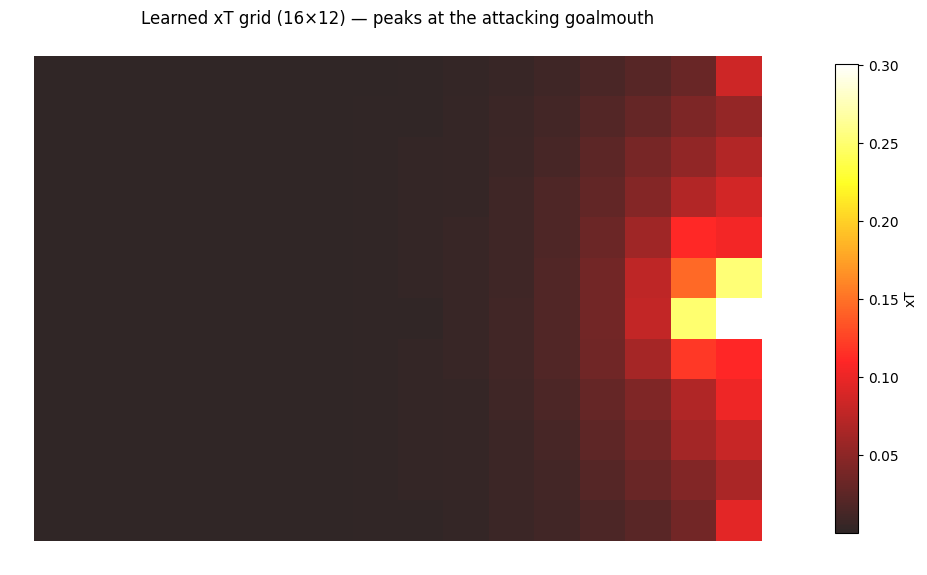

: 

In [ ]:
grid = np.load(DATA / "xt_grid.npy")  # (n_x, n_y) = (16, 12)
print("xT grid shape:", grid.shape, "| max:", round(float(grid.max()), 4))

pitch = Pitch(pitch_type="statsbomb", line_color="white")
fig, ax = pitch.draw(figsize=(10, 7))
x_edges = np.linspace(0, 120, grid.shape[0] + 1)
y_edges = np.linspace(0, 80, grid.shape[1] + 1)
mesh = ax.pcolormesh(x_edges, y_edges, grid.T, cmap="hot", alpha=0.85)
fig.colorbar(mesh, ax=ax, shrink=0.7, label="xT")
ax.set_title("Learned xT grid (16×12) — peaks at the attacking goalmouth")
plt.show()

---
**Next (Week 3):** `data/graphs.py` — turn each trigger freeze frame into a
`torch_geometric.data.Data` graph (node / edge / global features), then the geometric
baselines (B1 engineered, B2 pitch control, B3 OBSO).